### 데이터의 불균형 문제
- 정상을 정확하게 분류하는 것과 이상을 정확하게 분류하는 것 중 이상을 정확하게 분류하는 것이 중요
- 일반적으로는 정상의 데이터가 이상의 데이터보다 많다.
- 데이터의 불균형이 발생할 수 있다.
- target 데이터에서 0(정상), 1(이상) 중에 0을 판단을 더 많이 하게 되는 경우가 발생(예측력이 떨어진다.)
- 소수의 데이터의 중요도가 낮게 판단이 되서 실제 모델에서는 해당하는 예측이 적게 발생
- 다수의 데이터와 소수의 데이터를 특정 비율로 조절해주는 샘플링 기법이 존재(언더샘플링,오버샘플링)
- 샘플링을 사용하기 위한 라이브러리 설치(imbalanced-learn)

In [30]:
# !pip install imbalanced-learn

- 언더 샘플링
    - 다수의 라벨을 가진 데이터를 샘플링하여 소수의 데이터의 수 수준으로 감소 시키는 방법
    - 데이터의 불균형 문제는 해결이 되지만 전체 데이터의 개수가 감소하여 학습의 성능이 떨어질 수 있다.

In [31]:
import pandas as pd
from sklearn.datasets import make_classification
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler

In [32]:
#머신러닝에서는 독립변수와 종속 변수의 이름
#make_classfication() 함수는 데이터가 뷸균형인 랜덤 데이터를 생성 & 결과가 독립변수, 종속변수 따로 데이터를 재공

#불균형 데이터셋 생성
x,y=make_classification(
    n_samples=1000,
    n_features=5,
    weights=[0.9],
    flip_y=0
)

In [33]:
x

array([[-0.39252583, -2.13349637,  1.43762729, -0.88774644, -1.29830322],
       [-2.1949353 ,  0.05178224,  0.28314347,  0.68808216,  1.64545045],
       [-0.43507061, -1.02158268,  0.77962002, -0.39087375, -0.50457457],
       ...,
       [-0.77322197, -0.91120143,  1.56171465, -0.82304519, -1.09900227],
       [-1.08159275, -1.61100857,  0.10866396,  0.3615543 ,  0.84625828],
       [ 0.24462973,  0.91647039,  1.19045869, -0.96725612, -1.58652365]],
      shape=(1000, 5))

In [34]:
y

array([0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [35]:
Counter(y)

Counter({np.int64(0): 901, np.int64(1): 99})

In [36]:
#데이터프레임으로 생성
df=pd.DataFrame(x)
#target 데이터 y도 데이터프레임애 포함
df['target']=y

df.head()

,0,1,2,3,4,target
0,-0.392526,-2.133496,1.437627,-0.887746,-1.298303,0
1,-2.194935,0.051782,0.283143,0.688082,1.645450,0
2,-0.435071,-1.021583,0.779620,-0.390874,-0.504575,1
3,-0.214818,-1.665172,-0.531944,0.475202,0.803643,0
4,-1.061119,-0.747370,1.667304,-0.782678,-0.961774,0


In [37]:
#RandomUnderSampler 라는 class를 생성
undersampler=RandomUnderSampler()

In [38]:
under_x,under_y=undersampler.fit_resample(x,y)

In [39]:
under_df=pd.DataFrame(under_x)
under_df['target']=under_y

under_df['target'].value_counts()

target
0    99
1    99
Name: count, dtype: int64

In [40]:
#undersampler에서 데이터의 비율을 변경
#class 생성할떄 비율을 지정
#sampling_strategy 매개변수 -> 소수의 데이터의 비율을 의미
undersampler2=RandomUnderSampler(sampling_strategy=0.3)

In [41]:
under_x2,under_y2=undersampler2.fit_resample(x,y)

In [42]:
Counter(under_y2)

Counter({np.int64(0): 330, np.int64(1): 99})

- 오버 샘플링
    - 소수의 데이터를 다수의 데이터의 개수만큼 증가시켜 학습에 사용하기 위한 방법
    - 데이터의 손실이 없기 때문에 일반적으로는 언더샘플링보다는 자주 사용
- 랜덤 오버 샘플링
    - 소수의 데이터를 단순 복제하여 다수의 데이터와의 비율을 맞춰주는 과정
    - 데이터가 단순하게 복제가 되기 때문에 데이터의 분포가 변하지 않는다.
    - 단순하게 증가시키기 때문에 추가적인 가중치가 발생
    - 오버피팅(과적합)의 위험성이 존재하지만 데이터 불균형 문제를 해결하는 것이 더 중요

In [43]:
from imblearn.over_sampling import RandomOverSampler

In [44]:
oversampler=RandomOverSampler()

In [45]:
over_x,over_y=oversampler.fit_resample(x,y)

In [46]:
Counter(over_y)

Counter({np.int64(0): 901, np.int64(1): 901})

In [47]:
#소수의 데이터 비율을 다수의 반정도로 샘플링
oversampler2=RandomOverSampler(sampling_strategy=0.5)

In [48]:
over_x2,over_y2=oversampler2.fit_resample(x,y)

In [49]:
Counter(over_y2)

Counter({np.int64(0): 901, np.int64(1): 450})

- SMOTE
    - 소수의 데이터의 관측값에 대한 k개으 최근접 양수를 이웃으로 찾고, 관측값과 이웃을 선택된 값 사이에 임의의 새로운 데이터를 생성하는 방법

In [50]:
from imblearn.over_sampling import SMOTE

In [51]:
smote=SMOTE()

In [52]:
sm_x,sm_y=smote.fit_resample(x,y)

In [53]:
Counter(sm_y)

Counter({np.int64(0): 901, np.int64(1): 901})

In [54]:
#실제 만들어진 샘플링 데이터의 분포를 확인
import matplotlib.pyplot as plt
import seaborn as sns

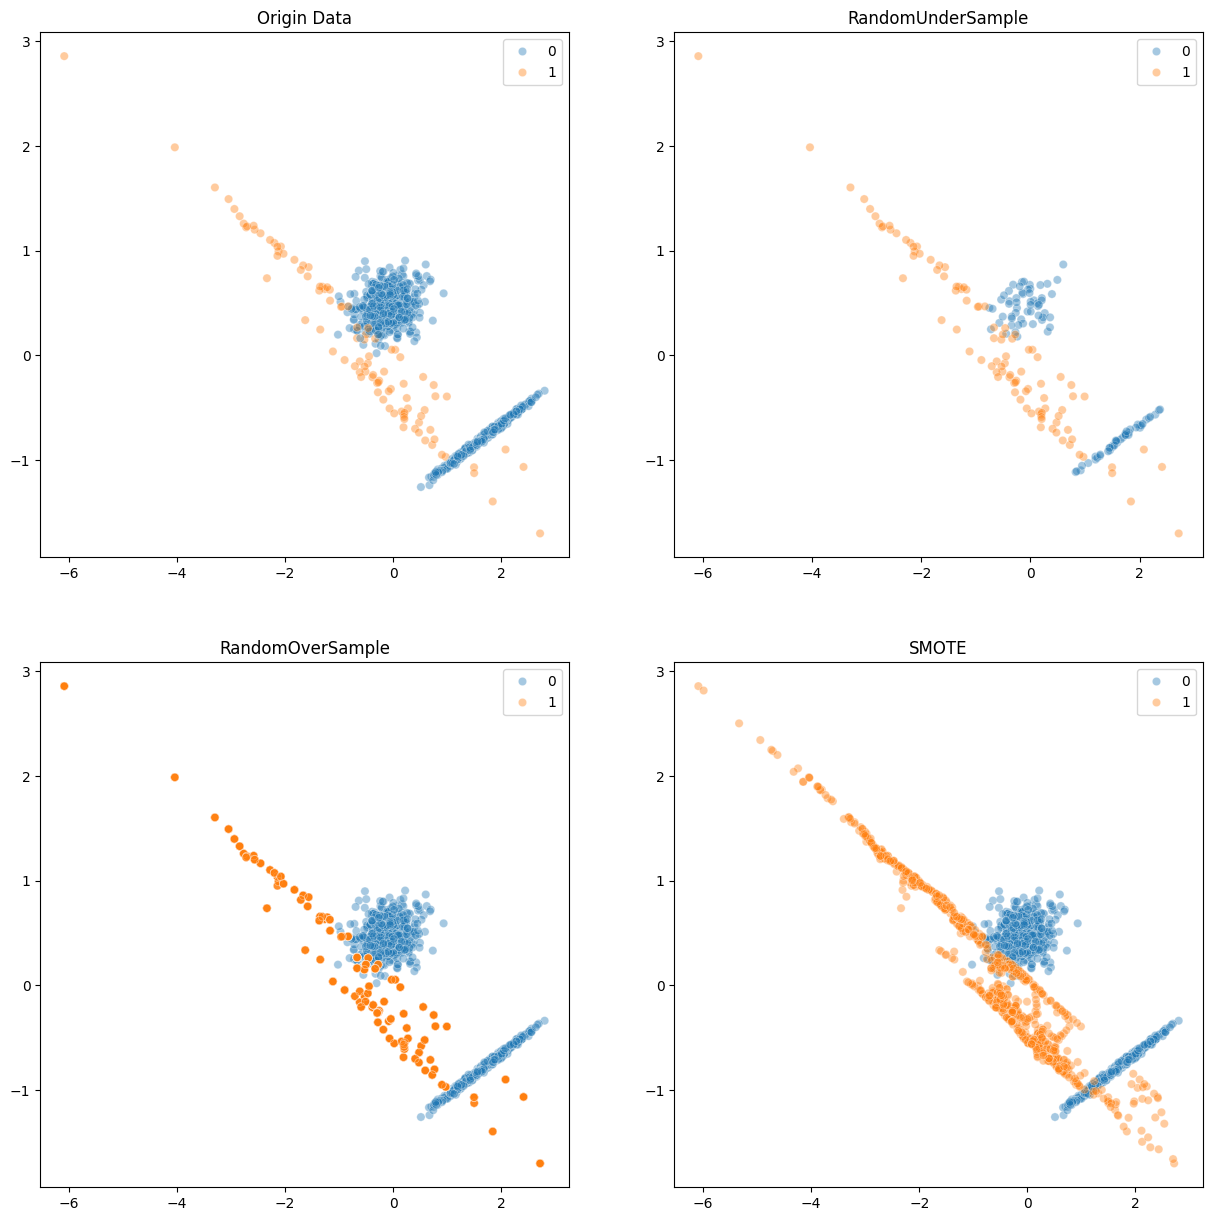

In [55]:
flg,axes=plt.subplots(2,2, figsize=(15,15))

#4개의 산점도 그래프 생성
sns.scatterplot(
    x = x[:,2],
    y = x[:,3],
    ax = axes[0][0],
    hue = y,
    alpha = 0.4
)
sns.scatterplot(
    x = under_x[:,2],
    y = under_x[:,3],
    ax = axes[0][1],
    hue = under_y,
    alpha = 0.4
)
sns.scatterplot(
    x = over_x[:,2],
    y = over_x[:,3],
    ax = axes[1][0],
    hue = over_y,
    alpha = 0.4
)
sns.scatterplot(
    x = sm_x[:,2],
    y = sm_x[:,3],
    ax = axes[1][1],
    hue = sm_y,
    alpha =0.4
)
axes[0][0].set_title('Origin Data')
axes[0][1].set_title('RandomUnderSample')
axes[1][0].set_title('RandomOverSample')
axes[1][1].set_title('SMOTE')

plt.show()